In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import models, datasets
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [ ]:
!unzip -oq ./chip_data.zip -d data

In [ ]:
dataset_path = "./data/dataset/"
train_dataset = datasets.ImageFolder(root=f"{dataset_path}/train", transform=transform)
test_dataset = datasets.ImageFolder(root=f"{dataset_path}/test", transform=transform)

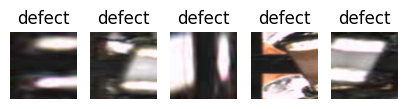

In [ ]:
def show_sample_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(5, 5))
    for i in range(num_images):
        image, label = dataset[i]
        image = image.permute(1, 2, 0)
        axes[i].imshow(image)
        axes[i].set_title(dataset.classes[label])
        axes[i].axis("off")
    plt.show()

show_sample_images(train_dataset)

In [ ]:
print(f"Total number of training samples: {len(train_dataset)}")
first_image, label = train_dataset[0]
print(f"Shape of the first image: {first_image.shape}")

print(f"Total number of testing samples: {len(test_dataset)}")
first_image_test, label_test = test_dataset[0]
print(f"Shape of the first test image: {first_image_test.shape}")

Total number of training samples: 172
Shape of the first image: torch.Size([3, 224, 224])
Total number of testing samples: 121
Shape of the first test image: torch.Size([3, 224, 224])


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
from torchvision.models import vgg19, VGG19_Weights
model = vgg19(weights=VGG19_Weights.DEFAULT)

In [ ]:
in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, 1)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
from torchsummary import summary
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [ ]:
for param in model.features.parameters():
    param.requires_grad = False

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

In [ ]:
def train_model(model, train_loader,test_loader,num_epochs=10):
    train_losses = []
    val_losses = []
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_losses.append(running_loss / len(train_loader))

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_losses.append(val_loss / len(test_loader))
        model.train()

        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f}')

    print("Name: Mithun Kumar G")
    print("Register Number: 212224230160")

    plt.figure(figsize=(8, 6))
    plt.plot(range(1, num_epochs + 1), train_losses)
    plt.plot(range(1, num_epochs + 1), val_losses)
    plt.show()

Epoch [1/10], Train Loss: 1.5489, Validation Loss: 0.2884
Epoch [2/10], Train Loss: 0.3282, Validation Loss: 0.9315
Epoch [3/10], Train Loss: 0.2105, Validation Loss: 0.1537
Epoch [4/10], Train Loss: 0.0581, Validation Loss: 0.1363
Epoch [5/10], Train Loss: 0.0026, Validation Loss: 0.0965
Epoch [6/10], Train Loss: 0.0045, Validation Loss: 0.1391
Epoch [7/10], Train Loss: 0.0026, Validation Loss: 0.1360
Epoch [8/10], Train Loss: 0.0000, Validation Loss: 0.0765
Epoch [9/10], Train Loss: 0.0000, Validation Loss: 0.0752
Epoch [10/10], Train Loss: 0.0001, Validation Loss: 0.0770
Name: Mithun Kumar G
Register Number: 212224230160


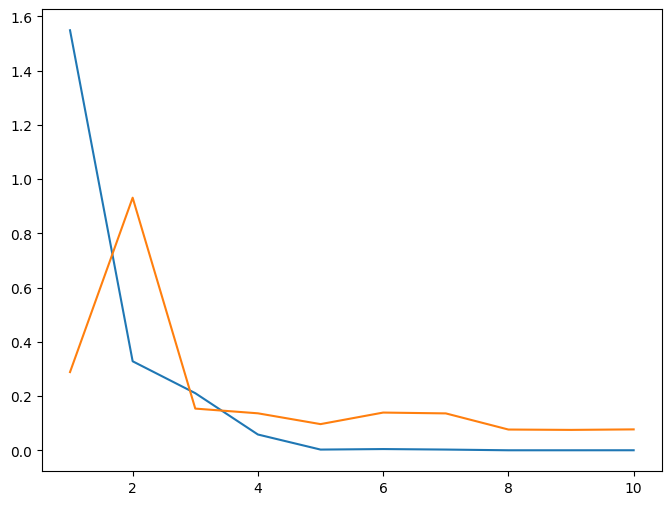

In [ ]:
train_model(model, train_loader, test_loader, num_epochs=10)

In [ ]:
def test_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)

            prob = torch.sigmoid(outputs)
            predicted = (prob > 0.5).int().squeeze()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    print("Name: Mithun Kumar G")
    print("Register Number: 212224230160")

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=train_dataset.classes,
                yticklabels=train_dataset.classes)
    plt.show()

    print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

Name: Mithun Kumar G
Register Number: 212224230160


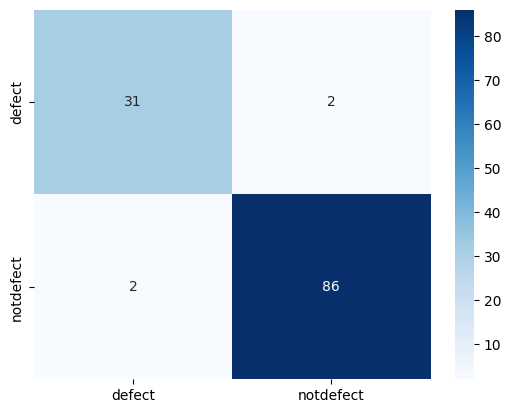

              precision    recall  f1-score   support

      defect       0.94      0.94      0.94        33
   notdefect       0.98      0.98      0.98        88

    accuracy                           0.97       121
   macro avg       0.96      0.96      0.96       121
weighted avg       0.97      0.97      0.97       121



In [ ]:
test_model(model, test_loader)

In [ ]:
def predict_image(model, image_index, dataset):
    model.eval()
    image, label = dataset[image_index]
    with torch.no_grad():
        image_tensor = image.unsqueeze(0).to(device)
        output = model(image_tensor)
        prob = torch.sigmoid(output)
        predicted = (prob > 0.5).int().item()

    class_names = dataset.classes
    image_to_display = transforms.ToPILImage()(image)
    plt.imshow(image_to_display)
    plt.title(f'Actual: {class_names[label]} | Predicted: {class_names[predicted]}')
    plt.axis("off")
    plt.show()

    print("Name: Mithun Kumar G")
    print("Register Number: 212224230160")

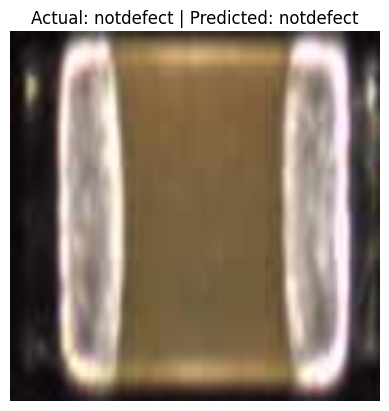

Name: Mithun Kumar G
Register Number: 212224230160


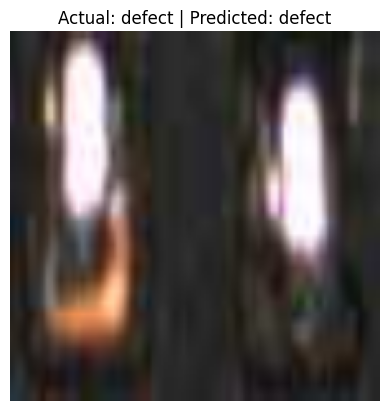

Name: Mithun Kumar G
Register Number: 212224230160


In [ ]:
predict_image(model, image_index=55, dataset=test_dataset)
predict_image(model, image_index=25, dataset=test_dataset)